Random Forest R2 Score: 0.7737


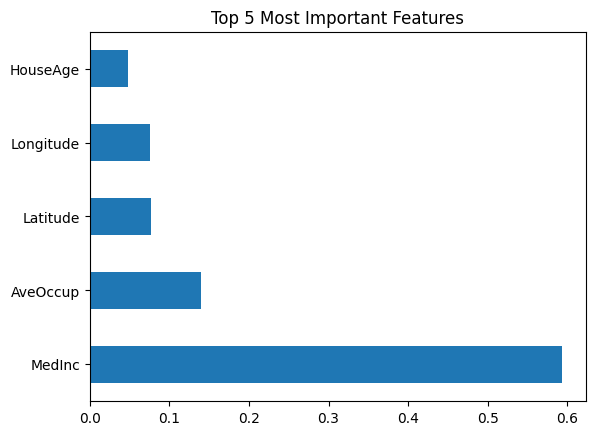

In [1]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

data = fetch_california_housing()
X_train, X_test, y_train, y_test = train_test_split(data.data, data.target, test_size = 0.2, random_state=42)

rf_model = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)
rf_model.fit(X_train, y_train)

predictions = rf_model.predict(X_test)
print(f"Random Forest R2 Score: {r2_score(y_test, predictions):.4f}") 

import matplotlib.pyplot as plt
import pandas as pd

importances = rf_model.feature_importances_
feature_names = data.feature_names
feat_importances = pd.Series(importances, index=feature_names) 
feat_importances.nlargest(5).plot(kind='barh') 
plt.title("Top 5 Most Important Features") 
plt.show()

In [4]:
import time

trees = [10, 50, 100, 200]

for n in trees:
    start = time.time()
    
    model = RandomForestRegressor(n_estimators=n, max_depth=10, random_state=42)
    model.fit(X_train, y_train)
    
    preds = model.predict(X_test)
    r2 = r2_score(y_test, preds)
    
    end = time.time()
    
    print(f"Trees: {n}, R2: {r2:.4f}, Time: {end-start:.2f}s")

Trees: 10, R2: 0.7619, Time: 1.59s
Trees: 50, R2: 0.7732, Time: 7.02s
Trees: 100, R2: 0.7737, Time: 14.07s
Trees: 200, R2: 0.7748, Time: 26.96s


As the number of trees increases, the model’s performance improves initially due to better averaging and reduced variance. However, after a certain point, the improvement becomes minimal, leading to diminishing returns, while computational cost continues to increase significantly.